In [1]:
import os
import time
from functools import partial
from typing import Callable, Sequence

import flax.linen as nn
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import scipy.io
from flax import serialization
from soap_jax import soap

from Utilities_pinn_burgers2d01 import *

In [ ]:
# 1. Data
data_path = "Burgers_2D.mat"
data = scipy.io.loadmat(data_path)

# U 已经按照 (Nt, Ny, Nx) 保存
U_data = jnp.asarray(data["U"])

Nt, Ny, Nx = U_data.shape

# MATLAB 中是一行向量，reshape(-1) 转成一维
t = jnp.asarray(data["t"]).reshape(-1)
x = jnp.asarray(data["x"]).reshape(-1)
y = jnp.asarray(data["y"]).reshape(-1)

assert t.shape[0] == Nt
assert x.shape[0] == Nx
assert y.shape[0] == Ny

# 构造 (Nt, Ny, Nx) 坐标张量
# broadcast_to 在表达层面不需要先存储三份完整坐标数据
T_data = jnp.broadcast_to(t[:, None, None], (Nt, Ny, Nx))
X_data = jnp.broadcast_to(x[None, None, :], (Nt, Ny, Nx))
Y_data = jnp.broadcast_to(y[None, :, None], (Nt, Ny, Nx))

t0 = float(T_data[0, 0, 0])
tend = float(T_data[-1, 0, 0])

xL = float(X_data[0, 0, 0])
xR = float(X_data[0, 0, -1])

yL = float(Y_data[0, 0, 0])
yR = float(Y_data[0, -1, 0])

trange = (t0, tend)
xrange = (xL, xR)
yrange = (yL, yR)

T_grid = T_data
X_grid = X_data
Y_grid = Y_data

T_test = T_data[-1]
X_test = X_data[-1]
Y_test = Y_data[-1]
test_labels = U_data[-1].reshape(-1)
test_inputs = create_test_inputs(T_test, X_test, Y_test)

print(f"Data grid: Nt={Nt}, Ny={Ny}, Nx={Nx}")
print(f"Time domain: {trange}")
print(f"x domain: {xrange}")
print(f"y domain: {yrange}")
print(f"Test snapshot: t={tend:.6g}")

Data grid: Nt=129, Ny=257, Nx=257
Time domain: (0.0, 1.0)
x domain: (0.0, 4.0)
y domain: (0.0, 4.0)
Test snapshot: t=1


In [3]:
# 2. Vanilla PINN: FNN_fourier receives only (t, x, y).
seed = 44
save_path = "pinn_burgers2d01_03.msgpack"

key = jax.random.PRNGKey(seed)
key_pde_init, key_train = jax.random.split(key, 2)

pde_net = FNN_fourier(
    layer_sizes=[40, 40, 1],
    activation=nn.silu,
)
pde_params = pde_net.init(
    key_pde_init,
    jnp.ones((3,), dtype=T_data.dtype),
)

# 3. One direct training stage at the target viscosity.
# Change this value if the reference data use another viscosity.
nu = 1.0e-3

pde_optimizer = soap(
    learning_rate=3.0e-3,
    b1=0.95,
    b2=0.95,
    weight_decay=0.01,
    precondition_frequency=10,
    precondition_1d=False,
)
pde_loss_grad_fn = create_pde_loss_grad_fn(
    pde_net,
    w_ic=10.0,
    w_bc=10.0,
)
pde_minibatch_fn = create_pde_minibatch_fn(
    IC_Burgers_2D,
    t_bounds=trange,
    x_bounds=xrange,
    y_bounds=yrange,
    dtype=T_data.dtype,
)
eval_fn = create_eval_fn(pde_net)

[Vanilla PINN] JIT warm-up finished.
[Vanilla PINN] iter=00000, time=0.00s | MSE=5.41e-01 | RL2=1.72e+00
[Vanilla PINN] iter=00100, time=0.98s, loss=1.89e+00 | MSE=1.74e-01 | RL2=9.73e-01
[Vanilla PINN] iter=00200, time=1.90s, loss=5.60e-01 | MSE=7.24e-02 | RL2=6.27e-01
[Vanilla PINN] iter=00300, time=2.81s, loss=2.77e-01 | MSE=3.14e-02 | RL2=4.13e-01
[Vanilla PINN] iter=00400, time=3.72s, loss=2.46e-01 | MSE=2.32e-02 | RL2=3.55e-01
[Vanilla PINN] iter=00500, time=4.62s, loss=2.36e-01 | MSE=2.04e-02 | RL2=3.33e-01
[Vanilla PINN] iter=00600, time=5.53s, loss=2.32e-01 | MSE=1.89e-02 | RL2=3.20e-01
[Vanilla PINN] iter=00700, time=6.44s, loss=2.27e-01 | MSE=1.76e-02 | RL2=3.09e-01
[Vanilla PINN] iter=00800, time=7.34s, loss=2.26e-01 | MSE=1.67e-02 | RL2=3.02e-01
[Vanilla PINN] iter=00900, time=8.25s, loss=2.22e-01 | MSE=1.59e-02 | RL2=2.94e-01
[Vanilla PINN] iter=01000, time=9.16s, loss=2.20e-01 | MSE=1.49e-02 | RL2=2.85e-01
[Vanilla PINN] iter=01100, time=10.06s, loss=2.22e-01 | MSE=1.43e

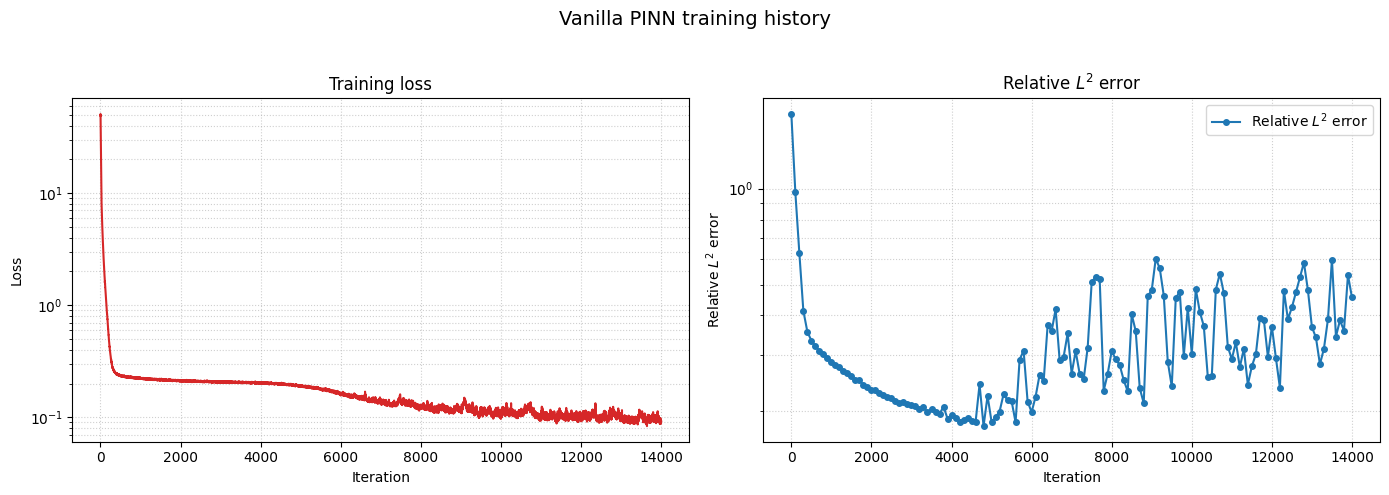

Plotting test grid: nt=1, ny=257, nx=257
Evaluation errors (excluding x+y=2 and x+y=6):
  Supplied test set: MSE=3.811576e-02, RL2=4.552399e-01
  Final time       : MSE=3.811576e-02, RL2=4.552399e-01
  Excluded points  : full=258, final=258


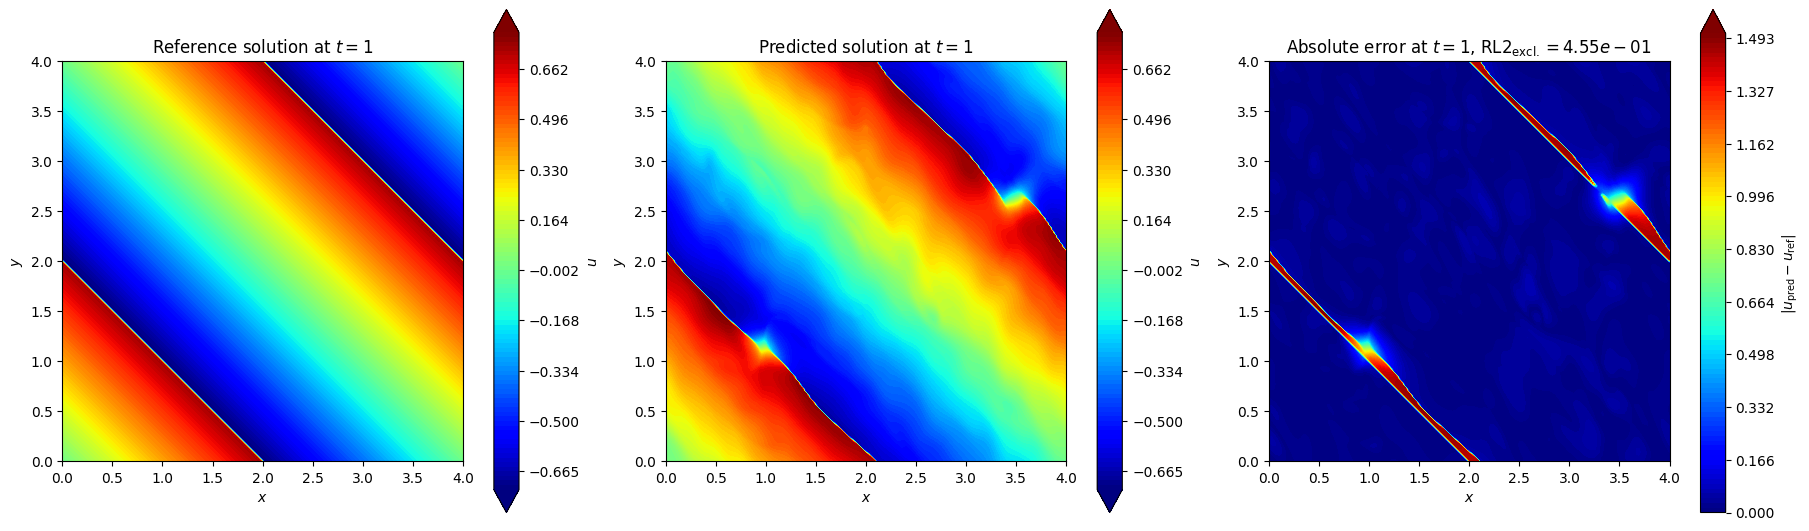

(np.float32(0.03811576), np.float32(0.45523992))

In [4]:
pde_params, key_train, history = train_pinn(
    pde_params=pde_params,
    pde_optimizer=pde_optimizer,
    pde_loss_grad_fn=pde_loss_grad_fn,
    pde_minibatch_fn=pde_minibatch_fn,
    eval_fn=eval_fn,
    test_inputs=test_inputs,
    test_labels=test_labels,
    key=key_train,
    nu=nu,
    max_iters=14000,
    pts_pde=50000,
    pts_ics=5000,
    pts_bcs=5000,
    max_runtime=10000.0,
    eval_every=100,
)

plot_training_history(
    history,
    metric="rl2",
    title="Vanilla PINN training history",
)
plot_evaluation(
    params=pde_params,
    model=pde_net,
    t_test=T_test,
    x_test=X_test,
    y_test=Y_test,
    labels_test=test_labels,
)

In [5]:
save_training_results(
    pde_params=pde_params,
    history=history,
    checkpoint_path=save_path,
    metadata={
        "data_path": data_path,
        "seed": seed,
        "nu": nu,
        "test_time": tend,
        "max_iters": 14000,
        "pts_pde": 50000,
        "pts_ics": 5000,
        "pts_bcs": 5000,
        "eval_every": 100,
    },
)

Training checkpoint saved to: /home/DG21210022/Amon/tal/burgers2d/pinn_burgers2d01_03.msgpack
Training history saved to: /home/DG21210022/Amon/tal/burgers2d/pinn_burgers2d01_03_history.npz
